# Assignment 3 - Deliverable 1: SST-2 Task Analysis

## Step 1: Install and Import Libraries

In [18]:

%pip install datasets transformers pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Import libraries
from datasets import load_dataset
import pandas as pd
import numpy as np
import json
from collections import Counter
import matplotlib.pyplot as plt

## Step 2: Load SST-2 Dataset

In [20]:
# Load SST-2 from GLUE benchmark
print("Loading SST-2 dataset...")
dataset = load_dataset("glue", "sst2")
print("✓ Dataset loaded!")
print(f"\nAvailable splits: {list(dataset.keys())}")
dataset

Loading SST-2 dataset...
✓ Dataset loaded!

Available splits: ['train', 'validation', 'test']


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

## Step 3: Calculate Task Statistics

In [21]:
# Dataset sizes
print("="*60)
print("DATASET SIZES")
print("="*60)
for split in dataset.keys():
    print(f"{split.upper()}: {len(dataset[split]):,} examples")

DATASET SIZES
TRAIN: 67,349 examples
VALIDATION: 872 examples
TEST: 1,821 examples


In [22]:
# Class distribution
print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print("Labels: 0 = Negative, 1 = Positive\n")

for split in ['train', 'validation']:
    labels = dataset[split]['label']
    counter = Counter(labels)
    total = len(labels)
    
    print(f"{split.upper()}:")
    for label in sorted(counter.keys()):
        count = counter[label]
        percentage = (count / total) * 100
        sentiment = "Negative" if label == 0 else "Positive"
        print(f"  {sentiment} (label={label}): {count:,} ({percentage:.2f}%)")
    print()

CLASS DISTRIBUTION
Labels: 0 = Negative, 1 = Positive

TRAIN:
  Negative (label=0): 29,780 (44.22%)
  Positive (label=1): 37,569 (55.78%)

VALIDATION:
  Negative (label=0): 428 (49.08%)
  Positive (label=1): 444 (50.92%)



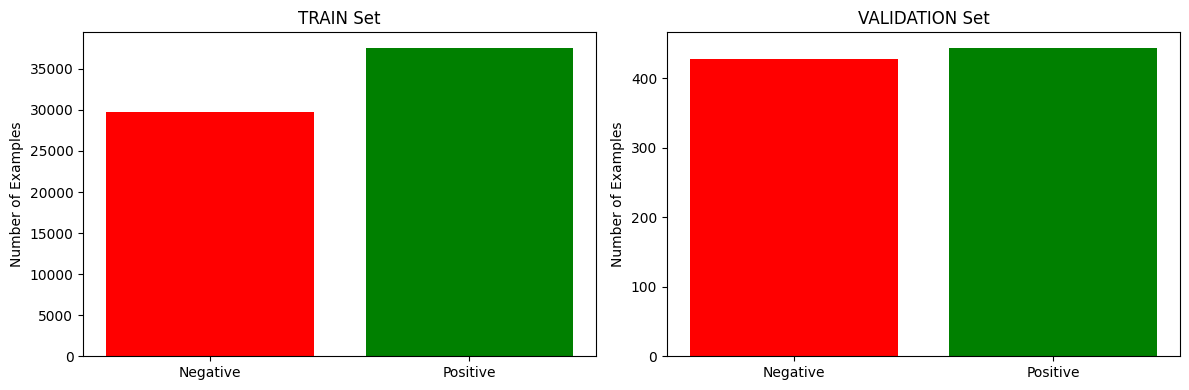

In [23]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, split in enumerate(['train', 'validation']):
    labels = dataset[split]['label']
    counter = Counter(labels)
    
    axes[idx].bar(['Negative', 'Positive'], 
                  [counter[0], counter[1]], 
                  color=['red', 'green'])
    axes[idx].set_title(f'{split.upper()} Set')
    axes[idx].set_ylabel('Number of Examples')
    
plt.tight_layout()
plt.savefig('sst2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Sentence length statistics
print("="*60)
print("SENTENCE LENGTH STATISTICS")
print("="*60)

for split in ['train', 'validation']:
    sentences = dataset[split]['sentence']
    lengths = [len(s.split()) for s in sentences]
    
    print(f"\n{split.upper()}:")
    print(f"  Average: {np.mean(lengths):.2f} words")
    print(f"  Median: {np.median(lengths):.0f} words")
    print(f"  Min: {np.min(lengths)} words")
    print(f"  Max: {np.max(lengths)} words")
    print(f"  Std: {np.std(lengths):.2f} words")

SENTENCE LENGTH STATISTICS

TRAIN:
  Average: 9.41 words
  Median: 7 words
  Min: 1 words
  Max: 52 words
  Std: 8.07 words

VALIDATION:
  Average: 19.55 words
  Median: 19 words
  Min: 2 words
  Max: 47 words
  Std: 8.76 words


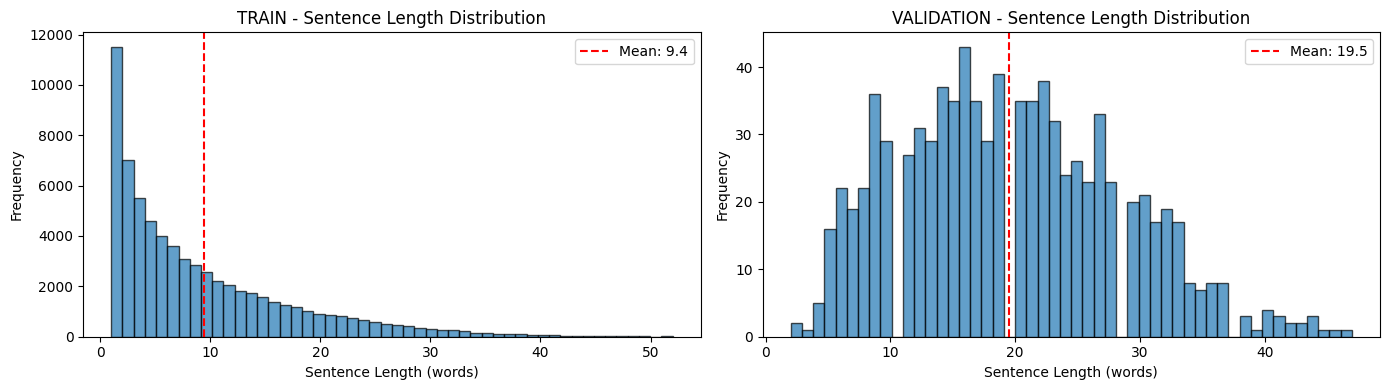

In [25]:
# Visualize sentence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, split in enumerate(['train', 'validation']):
    sentences = dataset[split]['sentence']
    lengths = [len(s.split()) for s in sentences]
    
    axes[idx].hist(lengths, bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{split.upper()} - Sentence Length Distribution')
    axes[idx].set_xlabel('Sentence Length (words)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('sst2_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Show Task Examples

In [26]:
# Show positive examples
print("="*60)
print("POSITIVE EXAMPLES (label=1)")
print("="*60)

train_data = dataset['train']
positive_indices = [i for i, label in enumerate(train_data['label']) if label == 1]

for i, idx in enumerate(positive_indices[:10], 1):
    print(f"{i}. \"{train_data['sentence'][idx]}\"")
    print()

POSITIVE EXAMPLES (label=1)
1. "that loves its characters and communicates something rather beautiful about human nature "

2. "demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . "

3. "of saucy "

4. "are more deeply thought through than in most ` right-thinking ' films "

5. "the greatest musicians "

6. "with his usual intelligence and subtlety "

7. "swimming is above all about a young woman 's face , and by casting an actress whose face projects that woman 's doubts and yearnings , it succeeds . "

8. "equals the original and in some ways even betters it "

9. "if anything , see it for karen black , who camps up a storm as a fringe feminist conspiracy theorist named dirty dick . "

10. "a smile on your face "



In [27]:
# Show negative examples
print("="*60)
print("NEGATIVE EXAMPLES (label=0)")
print("="*60)

negative_indices = [i for i, label in enumerate(train_data['label']) if label == 0]

for i, idx in enumerate(negative_indices[:10], 1):
    print(f"{i}. \"{train_data['sentence'][idx]}\"")
    print()

NEGATIVE EXAMPLES (label=0)
1. "hide new secretions from the parental units "

2. "contains no wit , only labored gags "

3. "remains utterly satisfied to remain the same throughout "

4. "on the worst revenge-of-the-nerds clichés the filmmakers could dredge up "

5. "that 's far too tragic to merit such superficial treatment "

6. "a depressed fifteen-year-old 's suicidal poetry "

7. "goes to absurd lengths "

8. "for those moviegoers who complain that ` they do n't make movies like they used to anymore "

9. "the part where nothing 's happening , "

10. "saw how bad this movie was "



## Step 5: Create DataFrame

In [28]:
# Create pandas DataFrame from validation set for easy browsing
val_data = dataset['validation']

df = pd.DataFrame({
    'idx': val_data['idx'],
    'sentence': val_data['sentence'],
    'label': val_data['label'],
    'sentiment': ['Positive' if l == 1 else 'Negative' for l in val_data['label']],
    'word_count': [len(s.split()) for s in val_data['sentence']]
})

print(f"Created DataFrame with {len(df)} validation examples")
df.head(20)

Created DataFrame with 872 validation examples


,idx,sentence,label,sentiment,word_count
0,0,it 's a charming and often affecting journey .,1,Positive,9
1,1,unflinchingly bleak and desperate,0,Negative,4
2,2,allows us to hope that nolan is poised to emba...,1,Positive,20
3,3,"the acting , costumes , music , cinematography...",1,Positive,20
4,4,"it 's slow -- very , very slow .",0,Negative,9
5,5,although laced with humor and a few fanciful t...,1,Positive,21
6,6,a sometimes tedious film .,0,Negative,5
7,7,or doing last year 's taxes with your ex-wife .,0,Negative,10
8,8,you do n't have to know about music to appreci...,1,Positive,20
9,9,"in exactly 89 minutes , most of which passed a...",0,Negative,33


## Step 6: Browse Instances to Find Easy and Difficult Examples


In [29]:
# Browse different parts of the validation set

start_idx = 0
num_rows = 50

df[start_idx:start_idx+num_rows]

,idx,sentence,label,sentiment,word_count
0,0,it 's a charming and often affecting journey .,1,Positive,9
1,1,unflinchingly bleak and desperate,0,Negative,4
2,2,allows us to hope that nolan is poised to emba...,1,Positive,20
3,3,"the acting , costumes , music , cinematography...",1,Positive,20
4,4,"it 's slow -- very , very slow .",0,Negative,9
5,5,although laced with humor and a few fanciful t...,1,Positive,21
6,6,a sometimes tedious film .,0,Negative,5
7,7,or doing last year 's taxes with your ex-wife .,0,Negative,10
8,8,you do n't have to know about music to appreci...,1,Positive,20
9,9,"in exactly 89 minutes , most of which passed a...",0,Negative,33


In [30]:
# Looking short sentences
df_short = df[df['word_count'] <= 8].sort_values('word_count')
print(f"Found {len(df_short)} short sentences (≤ 8 words)")
df_short.head(30)

Found 87 short sentences (≤ 8 words)


,idx,sentence,label,sentiment,word_count
203,203,bad .,0,Negative,2
289,289,cool ?,1,Positive,2
652,652,very bad .,0,Negative,3
449,449,oh come on .,0,Negative,4
462,462,"yes , dull .",0,Negative,4
578,578,just not campy enough,0,Negative,4
1,1,unflinchingly bleak and desperate,0,Negative,4
573,573,lovely and poignant .,1,Positive,4
112,112,hilariously inept and ridiculous .,1,Positive,5
744,744,one from the heart .,1,Positive,5


In [31]:
# Looking long sentences
df_long = df[df['word_count'] >= 20].sort_values('word_count', ascending=False)
print(f"Found {len(df_long)} long sentences (≥ 20 words)")
df_long.head(30)

Found 415 long sentences (≥ 20 words)


,idx,sentence,label,sentiment,word_count
104,104,it 's one of those baseball pictures where the...,1,Positive,47
334,334,what really makes it special is that it pulls ...,1,Positive,46
440,440,"this is wild surreal stuff , but brilliant and...",1,Positive,45
163,163,slapstick buffoonery can tickle many a prescho...,0,Negative,44
438,438,the movie has an infectious exuberance that wi...,1,Positive,44
79,79,this is a train wreck of an action film -- a s...,0,Negative,44
459,459,gives you the steady pulse of life in a beauti...,1,Positive,43
804,804,but the power of these ( subjects ) is obscure...,0,Negative,43
862,862,"it 's inoffensive , cheerful , built to inspir...",0,Negative,42
758,758,"may be far from the best of the series , but i...",1,Positive,42


In [32]:
# Searchin sentences with specific words
negation_words = ['not', 'no', 'never', 'hardly', 'barely', 'scarcely']

df_negations = df[df['sentence'].str.lower().str.contains('|'.join(negation_words))]
print(f"Found {len(df_negations)} sentences with negations")
df_negations.head(20)

Found 223 sentences with negations


,idx,sentence,label,sentiment,word_count
2,2,allows us to hope that nolan is poised to emba...,1,Positive,20
8,8,you do n't have to know about music to appreci...,1,Positive,20
14,14,even horror fans will most likely not find wha...,0,Negative,25
20,20,pumpkin takes an admirable look at the hypocri...,0,Negative,32
34,34,"it does n't believe in itself , it has no sens...",0,Negative,20
36,36,"the weight of the piece , the unerring profess...",1,Positive,26
42,42,the subtle strength of `` elling '' is that it...,1,Positive,21
44,44,the title not only describes its main characte...,0,Negative,19
59,59,it 's just disappointingly superficial -- a mo...,0,Negative,32
65,65,you wonder why enough was n't just a music vid...,0,Negative,16
